In [1]:
import pickle
import pandas as pd

file = pickle.load(open('/home/caron/Bureau/df_test_full_all_departement_0_None_node.pkl', 'rb'))
file

/tmp/ipykernel_246689/3226004033.py:4: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  file = pickle.load(open('/home/caron/Bureau/df_test_full_all_departement_0_None_node.pkl', 'rb'))


,Châtaignier_max,Chênes décidus_max,Chênes décidus_mean,Chênes sempervirents_max,Conifères_max,Conifères_mean,Corine_agricultural_max,Corine_agricultural_mean,Corine_forest_max,Corine_forest_mean,...,saison-cluster-encoder,burnedarea-kmeans-5-Class-Dept,nbsinister-binary,burnedarea,nbsinister-kmeans-5-Class-Dept_prev,nbsinister-kmeans-5-Class-Dept_prev_0,nbsinister-kmeans-5-Class-Dept_prev_1,nbsinister-kmeans-5-Class-Dept_prev_2,nbsinister-kmeans-5-Class-Dept_prev_3,nbsinister-kmeans-5-Class-Dept_prev_4
0,0.321793,0.883569,-0.105392,-0.403492,0.653882,1.058149,0.308431,0.237727,0.405302,1.320516,...,low-0.027,0,0,0.0,0,1,0,0,0,0
1,-0.866421,0.361931,-0.085671,-0.403492,-0.583628,-0.516837,0.315391,-0.026700,0.405302,0.087940,...,low-0.027,0,0,0.0,0,1,0,0,0,0
2,-0.192296,-0.283347,-0.854361,-0.140858,-0.758851,-0.524236,0.315391,1.173928,-1.073137,-1.595834,...,low-0.027,0,0,0.0,0,1,0,0,0,0
3,2.616005,0.861786,2.433646,0.492149,-0.906920,-0.495776,0.315391,-0.130316,-0.244292,1.219982,...,low-0.323,0,0,0.0,0,1,0,0,0,0
4,-0.644012,-0.236410,-0.731266,-0.403492,-0.761696,-0.505453,0.289632,0.628165,0.398702,-0.879184,...,low-0.027,0,0,0.0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35323,0.040908,-0.543825,-0.362417,-0.403492,2.271694,0.518544,0.263633,-1.123581,0.077337,0.174961,...,low-0.027,0,0,0.0,0,1,0,0,0,0
35324,-0.675299,0.484207,0.403022,2.572094,0.709396,0.203775,0.315391,0.675174,0.405302,0.498684,...,low-0.027,0,0,0.0,0,1,0,0,0,0
35325,-0.866421,-0.972793,-0.795414,-0.403492,-0.342569,-0.385351,-0.507602,-0.821025,0.243299,1.510395,...,low-0.027,0,0,0.0,0,1,0,0,0,0
35326,-0.253771,0.523441,0.696455,-0.364064,0.561375,-0.472439,0.315391,-0.641606,0.162430,-0.044613,...,low-0.323,0,0,0.0,0,1,0,0,0,0


In [9]:
def create_model_config(clustering, conv_type, n_clusters, kernel):
    train_col = f"nbsinister-{clustering}-{n_clusters}-Class-Dept-{conv_type}-{kernel}"
    return train_col

def define_voting_dl_models():
    ##############################################
    res = []  # Liste pour contenir tous les modèles

    # Modèles m2
    for nb_clusters in ['1', '3', '5', 'Specialized']:
        model = create_model_config('kmeans', 'sum', '5', nb_clusters)
        res.append(model)

    # Modèles m3
    for nb_clusters in ['1', '3', '5', 'Specialized']:
        model = create_model_config('kmeans', 'max', '5', nb_clusters)
        res.append(model)

    # Modèles m4 avec différentes post-processings
    filters = ['median', 'cubic', 'mean', 'quartic', 'circular', 'gaussian']
    for aggregation in filters:
        for nb_clusters in ['1', '3', '5', 'Specialized']:
            """if aggregation == 'gaussian' and (nb_clusters == '3' or nb_clusters == '5'):
                continue
            elif aggregation == 'cubic' and nb_clusters == '3':
                continue
            elif aggregation == 'cubic' and nb_clusters == '5':
                continue
            elif aggregation == 'circular' and (nb_clusters == '1' or nb_clusters == '3' or nb_clusters == '5'):
                continue
            elif aggregation == 'quartic' and (nb_clusters == '3' or nb_clusters == '5'):
                continue
            elif aggregation == 'mean' and (nb_clusters == '1' or nb_clusters == '3' or nb_clusters == '5'):
                continue"""
            model = create_model_config('kmeans', aggregation, '5', nb_clusters)
            res.append(model)

    mlast = f'nbsinister-kmeans-5-Class-Dept'
    res.append(mlast)

    # Retourner la structure finale
    return res

cols = define_voting_dl_models()

In [12]:
file_y = file[['departement', 'date'] + cols]
file_y

,departement,date,nbsinister-kmeans-5-Class-Dept-sum-1,nbsinister-kmeans-5-Class-Dept-sum-3,nbsinister-kmeans-5-Class-Dept-sum-5,nbsinister-kmeans-5-Class-Dept-sum-Specialized,nbsinister-kmeans-5-Class-Dept-max-1,nbsinister-kmeans-5-Class-Dept-max-3,nbsinister-kmeans-5-Class-Dept-max-5,nbsinister-kmeans-5-Class-Dept-max-Specialized,...,nbsinister-kmeans-5-Class-Dept-quartic-Specialized,nbsinister-kmeans-5-Class-Dept-circular-1,nbsinister-kmeans-5-Class-Dept-circular-3,nbsinister-kmeans-5-Class-Dept-circular-5,nbsinister-kmeans-5-Class-Dept-circular-Specialized,nbsinister-kmeans-5-Class-Dept-gaussian-1,nbsinister-kmeans-5-Class-Dept-gaussian-3,nbsinister-kmeans-5-Class-Dept-gaussian-5,nbsinister-kmeans-5-Class-Dept-gaussian-Specialized,nbsinister-kmeans-5-Class-Dept
0,68,2009,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,8,2009,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,85,2009,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,24,2009,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,76,2009,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35323,65,2392,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
35324,84,2392,0,0,0,0,0,0,0,0,...,0,1,1,0,0,1,1,1,0,0
35325,25,2392,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
35326,64,2392,0,0,0,0,0,0,0,0,...,1,1,1,1,1,0,1,1,0,0


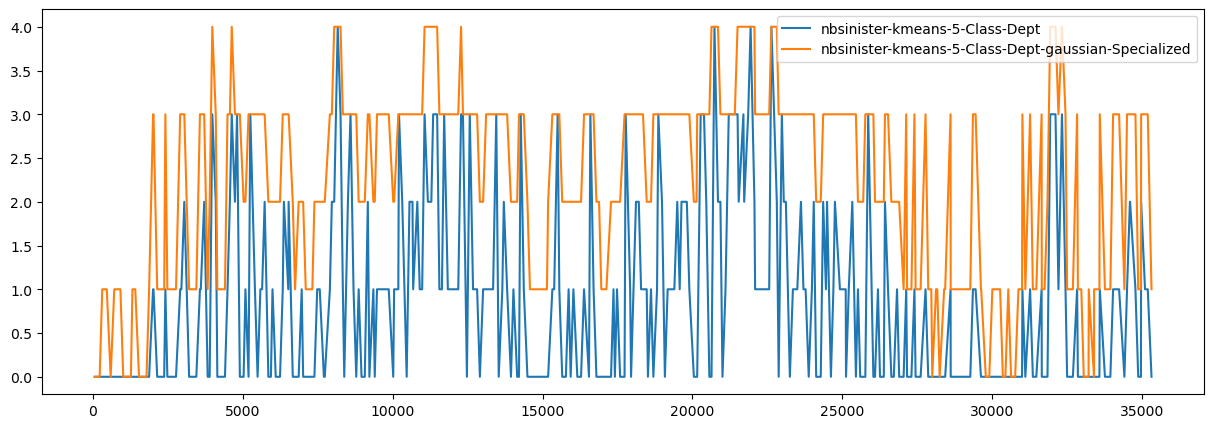

In [ ]:
import matplotlib.pyplot as plt

file_dept = file_y[file_y['departement'] == 83]

def plot_cols(cols, df):
    fig, ax = plt.subplots(1, figsize=(15,5))
    df.set_index('date')
    for col in cols:
        df[col].plot(ax=ax, label=col)
        
    plt.legend()
    plt.show()
    
plot_cols(['nbsinister-kmeans-5-Class-Dept', 'nbsinister-kmeans-5-Class-Dept-gaussian-Specialized'], file_dept.copy(deep=True))

In [24]:
import numpy as np

def signal_similarity(x, y, *, detrend=True, resample_to=None, eps=1e-12):
    """
    Similarité entre deux signaux 1D sous forme d'un score [-1, 1].
    - detrend=True : centre les signaux (≈ corrélation de Pearson).
    - resample_to : int pour tronquer/interpoler y à la taille de x (ou inversement).
    """
    x = np.asarray(x, dtype=float).ravel()
    y = np.asarray(y, dtype=float).ravel()

    if x.size == 0 or y.size == 0:
        raise ValueError("Signaux vides.")

    # Optionnel: mettre à la même longueur
    if resample_to is not None:
        n = int(resample_to)
        def _resample(sig, n):
            t_old = np.linspace(0, 1, sig.size)
            t_new = np.linspace(0, 1, n)
            return np.interp(t_new, t_old, sig)
        x = _resample(x, n)
        y = _resample(y, n)
    else:
        # si longueurs différentes: on compare sur la partie commune
        n = min(x.size, y.size)
        x, y = x[:n], y[:n]

    if detrend:
        x = x - x.mean()
        y = y - y.mean()

    # Cosine similarity (corrélation normalisée)
    denom = (np.linalg.norm(x) * np.linalg.norm(y)) + eps
    return float(np.dot(x, y) / denom)


dico = {}
for col in cols:
    for col_2 in cols:
        if col == col_2:
            continue
        dico[f'{col}_{col_2}'] = signal_similarity(file_y[col], file_y[col_2])
        
dico

{'nbsinister-kmeans-5-Class-Dept-sum-1_nbsinister-kmeans-5-Class-Dept-sum-3': 0.8688780619789143,
 'nbsinister-kmeans-5-Class-Dept-sum-1_nbsinister-kmeans-5-Class-Dept-sum-5': 0.8139982387002829,
 'nbsinister-kmeans-5-Class-Dept-sum-1_nbsinister-kmeans-5-Class-Dept-sum-Specialized': 0.8963947333525916,
 'nbsinister-kmeans-5-Class-Dept-sum-1_nbsinister-kmeans-5-Class-Dept-max-1': 0.9427819568541118,
 'nbsinister-kmeans-5-Class-Dept-sum-1_nbsinister-kmeans-5-Class-Dept-max-3': 0.8250643593274768,
 'nbsinister-kmeans-5-Class-Dept-sum-1_nbsinister-kmeans-5-Class-Dept-max-5': 0.7695120346795205,
 'nbsinister-kmeans-5-Class-Dept-sum-1_nbsinister-kmeans-5-Class-Dept-max-Specialized': 0.852489533160551,
 'nbsinister-kmeans-5-Class-Dept-sum-1_nbsinister-kmeans-5-Class-Dept-median-1': 0.6985490600288319,
 'nbsinister-kmeans-5-Class-Dept-sum-1_nbsinister-kmeans-5-Class-Dept-median-3': 0.6697322446668862,
 'nbsinister-kmeans-5-Class-Dept-sum-1_nbsinister-kmeans-5-Class-Dept-median-5': 0.6538951629

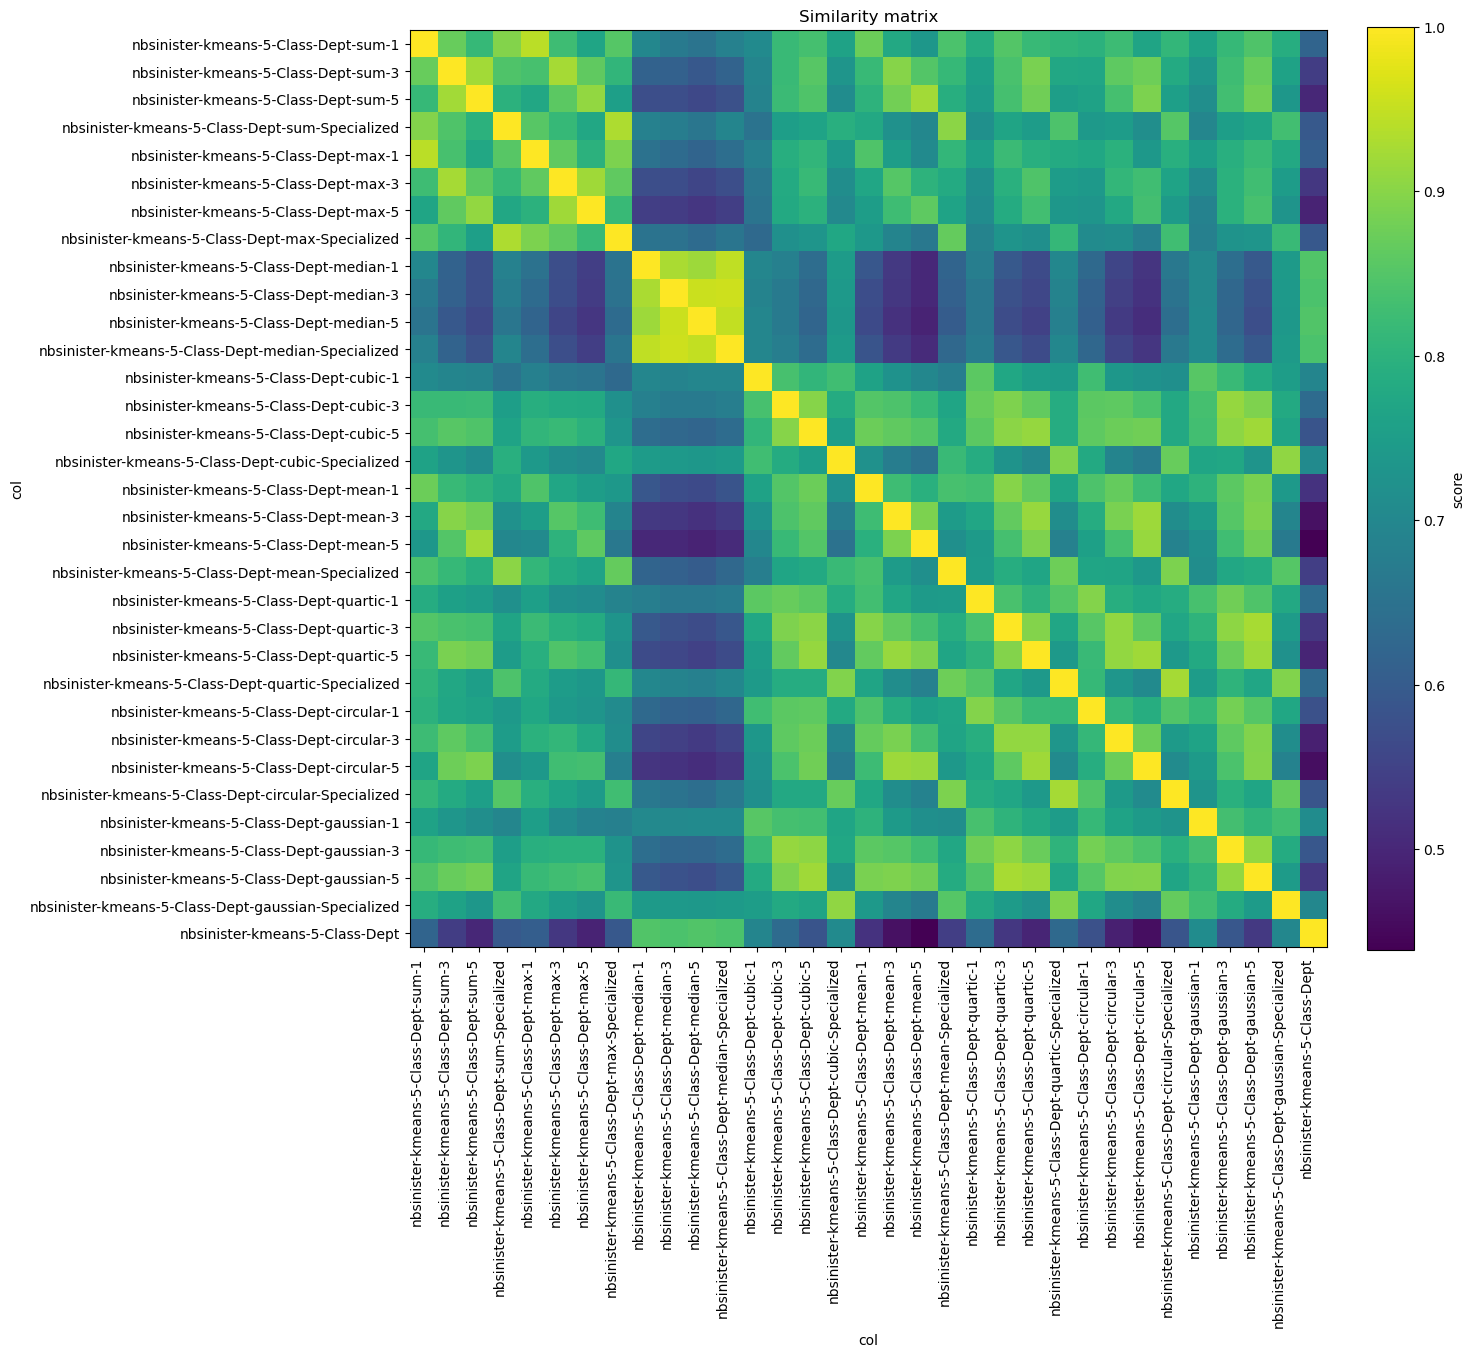

array([[1.        , 0.86887806, 0.81399824, ..., 0.84528337, 0.78845371,
        0.61901154],
       [0.86887806, 1.        , 0.92178   , ..., 0.86858506, 0.76171601,
        0.53966338],
       [0.81399824, 0.92178   , 1.        , ..., 0.88029337, 0.73622207,
        0.50074874],
       ...,
       [0.84528337, 0.86858506, 0.88029337, ..., 1.        , 0.74709867,
        0.532204  ],
       [0.78845371, 0.76171601, 0.73622207, ..., 0.74709867, 1.        ,
        0.69765606],
       [0.61901154, 0.53966338, 0.50074874, ..., 0.532204  , 0.69765606,
        1.        ]])

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_similarity_matrix(scores: dict, cols: list[str],
                           *, fill_diag=1.0, default=np.nan,
                           cmap="viridis", vmin=None, vmax=None,
                           annotate=False, figsize=None, title="Similarity matrix",
                           symmetric=True, key_sep="_", rotate_x=90):
    """
    Plot une matrice de similarité à partir d'un dict de la forme:
      {"col1_col2": score, ...}
    et d'une liste de colonnes `cols`.

    - symmetric=True : remplit [j,i] avec la même valeur que [i,j] (utile si ton dict ne contient qu'un sens)
    - fill_diag: valeur de la diagonale (souvent 1.0)
    - default: valeur par défaut si une paire manque (np.nan conseillé)
    - annotate=True : écrit les valeurs dans les cases
    - key_sep: séparateur entre col1 et col2 dans la clé (par défaut "_")
    """
    n = len(cols)
    idx = {c: i for i, c in enumerate(cols)}

    M = np.full((n, n), default, dtype=float)
    if fill_diag is not None:
        np.fill_diagonal(M, fill_diag)

    # remplir la matrice depuis le dictionnaire
    for k, val in scores.items():
        # split "col1_col2" -> col1, col2
        parts = k.split(key_sep, 1)  # split en 2 seulement (important si col1 contient aussi "_")
        if len(parts) != 2:
            continue
        c1, c2 = parts
        if c1 not in idx or c2 not in idx:
            continue
        i, j = idx[c1], idx[c2]
        M[i, j] = float(val)
        if symmetric:
            M[j, i] = float(val)

    # figsize par défaut un peu smart
    if figsize is None:
        s = max(6, min(18, 0.45 * n))
        figsize = (s, s)

    fig, ax = plt.subplots(figsize=figsize)

    im = ax.imshow(M, cmap=cmap, vmin=vmin, vmax=vmax)

    ax.set_title(title)
    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(cols, rotation=rotate_x, ha="right")
    ax.set_yticklabels(cols)

    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("score")

    # annotations
    if annotate:
        for i in range(n):
            for j in range(n):
                if np.isfinite(M[i, j]):
                    ax.text(j, i, f"{M[i,j]:.2f}", ha="center", va="center", fontsize=8)

    ax.set_xlabel("col")
    ax.set_ylabel("col")
    plt.tight_layout()
    plt.show()

    return M

plot_similarity_matrix(dico, cols)

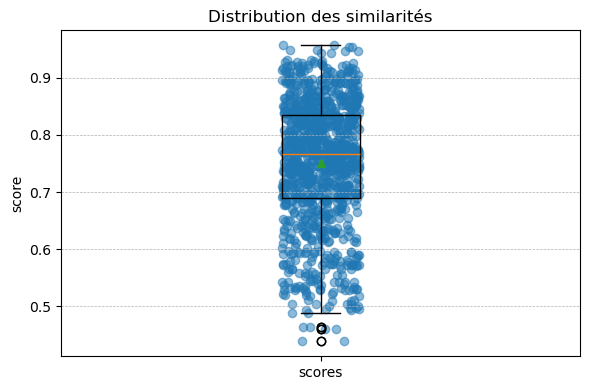

array([0.86887806, 0.81399824, 0.89639473, ..., 0.59059327, 0.532204  ,
       0.69765606])

In [42]:
import numpy as np
import matplotlib.pyplot as plt

def plot_score_boxplot(scores: dict,
                       *, title="Distribution des similarités",
                       show_points=True, figsize=(6, 4), ylabel="score"):
    """
    Boxplot des valeurs d'un dict {pair: score}.
    - show_points=True : superpose un nuage de points (jitter) pour voir la densité.
    """
    vals = np.array([float(v) for v in scores.values()], dtype=float)
    vals = vals[np.isfinite(vals)]

    if vals.size == 0:
        raise ValueError("Aucune valeur numérique finie dans `scores`.")

    fig, ax = plt.subplots(figsize=figsize)

    ax.boxplot(vals, vert=True, showmeans=True)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xticks([1])
    ax.set_xticklabels(["scores"])

    if show_points:
        # jitter horizontal léger
        x = 1 + (np.random.rand(vals.size) - 0.5) * 0.15
        ax.scatter(x, vals, alpha=0.5)

    ax.grid(True, axis="y", linestyle="--", linewidth=0.5)
    plt.tight_layout()
    plt.show()

    return vals


plot_score_boxplot(dico)